# Práctica 2 — Aprendizaje Semi-Supervisado en CIFAR-100

## Descripción
Se implementan técnicas de aprendizaje semi-supervisado y de una clase sobre CIFAR-100:

| Ejercicio | Técnica |
|-----------|----------|
| 1 | Clasificador supervisado (línea base) |
| 2 | Auto-aprendizaje (*self-training* con pseudo-etiquetas) |
| 3 | Autoencoder convolucional en dos pasos |
| 4 | Entrenamiento conjunto autoencoder + clasificador (un paso) |
| 5 | Filtrado de anomalías + auto-aprendizaje |
| 6 | Aprendizaje contrastivo (SCAN-*like*) |

**Partición:** 10 000 muestras etiquetadas · 40 000 sin etiquetar · 10 000 test · 100 clases.

## 0. Configuración global

Todos los hiperparámetros en un único diccionario para facilitar la reproducibilidad y ajuste.

In [ ]:
import tensorflow as tf
# Esto desactiva el optimizador de diseño de memoria 
tf.config.optimizer.set_experimental_options({"layout_optimizer": False})


import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

2026-04-10 18:43:58.348211: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 18:43:58.410110: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-04-10 18:44:01.978337: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
CFG = {
    # Reproducibilidad
    "seed": 42,
    # Partición de datos
    "frac_unlabeled": 0.80,
    "val_size": 0.20,
    "num_classes": 100,
    # Arquitectura compartida
    "filters": [64, 128, 256],
    "dense_units": 512,
    "dropout": 0.2,
    "l2_reg": 1e-4,
    # Optimizador
    "lr": 3e-4,
    "weight_decay": 1e-4,
    # Entrenamiento general
    "batch_size": 64,
    "ae_batch_size": 128,
    "epochs_baseline": 30,
    "epochs_ae": 15,
    "epochs_cls": 30,
    # Ejercicio 2 – auto-aprendizaje
    "st_epochs": 30,
    "st_iters": 5,
    "st_threshold": 0.95,
    # Ejercicio 4 – pérdida conjunta
    "joint_alpha": 0.5,
    # Ejercicio 5 – detector de anomalías
    "nu": 0.90,
    "anomaly_epochs": 15,
    "ad_delta": 0.025,
    "ad_patience": 3,
    # Ejercicio 6 – aprendizaje contrastivo
    "cl_tau": 5.0,
    "cl_lambda": 0.5,
    "cl_epochs": 8,
}


## 1. Importaciones

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    Flatten, Dense, Dropout, BatchNormalization,
    RandomRotation, RandomTranslation, RandomZoom, Resizing, RandomCrop,
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW, Adam
from sklearn.model_selection import train_test_split

SEED = CFG["seed"]
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"TensorFlow {tf.__version__} | Seed={SEED}")


TensorFlow 2.20.0 | Seed=42


## 2. Carga y preparación del dataset

In [4]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar100.load_data()
print(f"Train: {x_train_raw.shape}  |  Test: {x_test_raw.shape}")


Train: (50000, 32, 32, 3)  |  Test: (10000, 32, 32, 3)


In [5]:
num_train    = x_train_raw.shape[0]
num_unlabeled = int(num_train * CFG["frac_unlabeled"])
num_labeled  = num_train - num_unlabeled

rng = np.random.default_rng(SEED)
idx = rng.permutation(num_train)
labeled_idx, unlabeled_idx = idx[:num_labeled], idx[num_labeled:]

# Split etiquetado en train/val con estratificación
x_labeled_raw = x_train_raw[labeled_idx]
y_labeled_raw = y_train_raw[labeled_idx]

x_train_s, x_val, y_train_raw_s, y_val_raw = train_test_split(
    x_labeled_raw, y_labeled_raw,
    test_size=CFG["val_size"], random_state=SEED, stratify=y_labeled_raw
)

# Normalización [0, 1]
x_train      = x_train_s.astype("float32") / 255.0
x_val        = x_val.astype("float32")     / 255.0
x_test       = x_test_raw.astype("float32") / 255.0
x_unlabeled  = x_train_raw[unlabeled_idx].astype("float32") / 255.0

# One-hot encoding
y_train = to_categorical(y_train_raw_s.squeeze(), CFG["num_classes"])
y_val   = to_categorical(y_val_raw.squeeze(),     CFG["num_classes"])
y_test  = to_categorical(y_test_raw.squeeze(),    CFG["num_classes"])

print(f"Train etiquetado : {x_train.shape[0]}")
print(f"Validación       : {x_val.shape[0]}")
print(f"Sin etiquetar    : {x_unlabeled.shape[0]}")
print(f"Test             : {x_test.shape[0]}")


Train etiquetado : 8000
Validación       : 2000
Sin etiquetar    : 40000
Test             : 10000


### 2.1 Análisis exploratorio

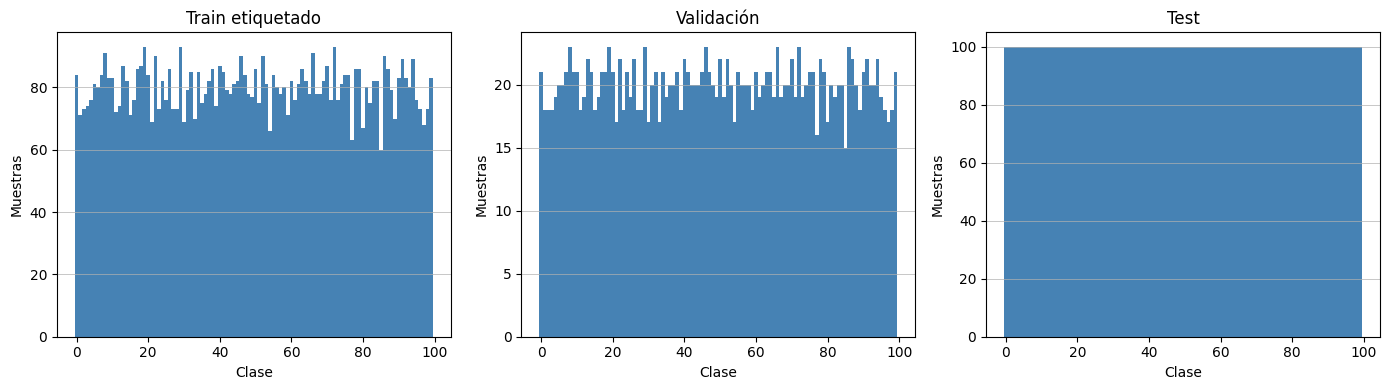

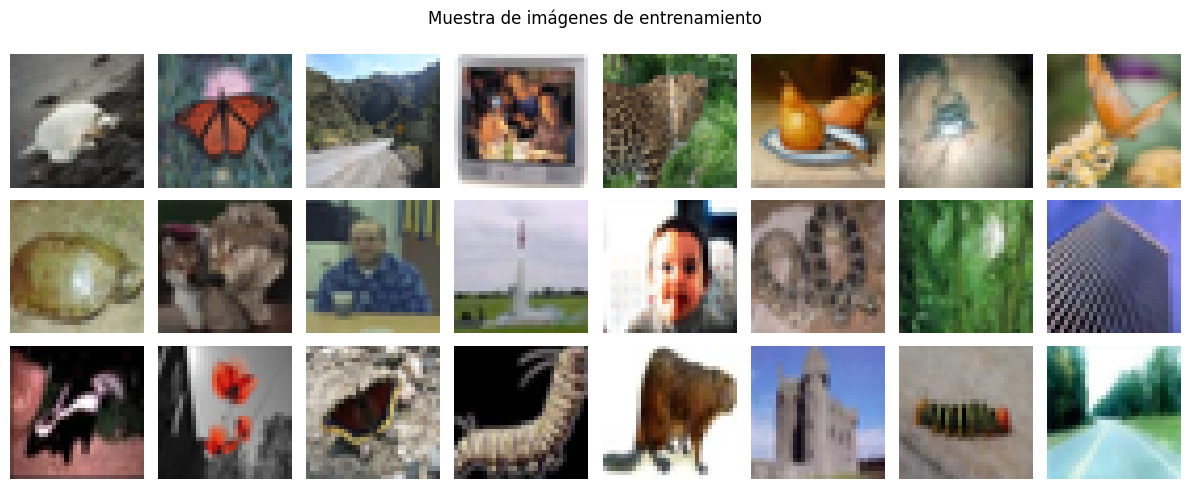

In [6]:
def plot_class_distribution(ys, titles, figsize=(14, 4)):
    """Distribución de clases para una lista de subconjuntos."""
    fig, axes = plt.subplots(1, len(ys), figsize=figsize, sharey=False)
    for ax, y, title in zip(axes, ys, titles):
        cls, cnt = np.unique(y.squeeze(), return_counts=True)
        ax.bar(cls, cnt, color="steelblue", width=1.0, edgecolor="none")
        ax.set_title(title)
        ax.set_xlabel("Clase")
        ax.set_ylabel("Muestras")
        ax.grid(axis="y", linewidth=0.5)
    plt.tight_layout()
    plt.show()

plot_class_distribution(
    [y_train_raw_s, y_val_raw, y_test_raw],
    ["Train etiquetado", "Validación", "Test"],
)

# Muestra de imágenes
fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for ax, img in zip(axes.flat, x_train[:24]):
    ax.imshow(img)
    ax.axis("off")
fig.suptitle("Muestra de imágenes de entrenamiento")
plt.tight_layout()
plt.show()


## 3. Arquitectura compartida

El mismo bloque encoder se reutiliza en todos los ejercicios.
Esto garantiza comparabilidad y evita duplicación de código.

In [7]:
def build_conv_encoder(
    input_shape=(32, 32, 3),
    filters=None,
    dropout=0.2,
    l2_reg=1e-4,
    name="encoder",
) -> Model:
    """
    Encoder convolucional de 3 bloques [Conv -> BN -> Conv -> MaxPool -> Dropout].

    Args:
        input_shape: Forma de la imagen (H, W, C).
        filters: Filtros por bloque, por defecto [64, 128, 256].
        dropout: Tasa de dropout tras cada bloque.
        l2_reg: Regularización L2 en las capas convolucionales.
        name: Nombre del modelo Keras.

    Returns:
        Modelo Keras funcional (encoder).
    """
    if filters is None:
        filters = [64, 128, 256]
    inputs = Input(shape=input_shape)
    x = inputs
    for i, f in enumerate(filters):
        x = Conv2D(f, (3, 3), activation="relu", padding="same",
                   kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = BatchNormalization()(x)
        x = Conv2D(f, (3, 3), activation="relu", padding="same")(x)
        x = MaxPooling2D((2, 2))(x)
        x = Dropout(dropout)(x)
    return Model(inputs, x, name=name)


def build_decoder(encoded_shape, filters=None, name="decoder") -> Model:
    """
    Decoder simétrico al encoder usando UpSampling2D.

    Args:
        encoded_shape: Forma del espacio latente (H', W', C').
        filters: Filtros en orden inverso, por defecto [256, 128, 64].
        name: Nombre del modelo Keras.

    Returns:
        Modelo Keras funcional (decoder).
    """
    if filters is None:
        filters = [256, 128, 64]
    enc_in = Input(shape=encoded_shape)
    x = enc_in
    for f in filters:
        x = UpSampling2D((2, 2))(x)
        x = Conv2D(f, (3, 3), activation="relu", padding="same")(x)
        x = BatchNormalization()(x)
    decoded = Conv2D(3, (3, 3), activation="sigmoid", padding="same")(x)
    return Model(enc_in, decoded, name=name)


def build_classifier_head(
    encoder: Model,
    num_classes: int,
    dense_units: int = 512,
    dropout: float = 0.2,
    l2_reg: float = 1e-4,
    name: str = "classifier",
) -> Model:
    """
    Cabeza clasificadora sobre un encoder Keras existente.

    Args:
        encoder: Modelo encoder Keras (puede estar congelado).
        num_classes: Número de clases de salida.
        dense_units: Neuronas de la capa densa intermedia.
        dropout: Tasa de dropout.
        l2_reg: Regularización L2.
        name: Nombre del modelo resultante.

    Returns:
        Modelo Keras funcional completo (encoder + cabeza).
    """
    x = Flatten()(encoder.output)
    x = Dense(dense_units, activation="relu",
              kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    out = Dense(num_classes, activation="softmax")(x)
    return Model(encoder.input, out, name=name)


def make_optimizer():
    """Instancia el optimizador AdamW con los hiperparámetros del CFG."""
    return AdamW(learning_rate=CFG["lr"], weight_decay=CFG["weight_decay"])


## 4. Funciones auxiliares

In [8]:
def plot_training(history, title: str = "", figsize=(12, 4)):
    """Curvas de pérdida y accuracy de un historial de entrenamiento Keras."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    epochs = range(1, len(history.history["loss"]) + 1)
    axes[0].plot(epochs, history.history["loss"],     label="Train")
    axes[0].plot(epochs, history.history["val_loss"], label="Val")
    axes[0].set_title(f"{title} — Pérdida")
    axes[0].set_xlabel("Época")
    axes[0].legend()
    axes[0].grid(linewidth=0.5)
    if "accuracy" in history.history:
        axes[1].plot(epochs, history.history["accuracy"],     label="Train")
        axes[1].plot(epochs, history.history["val_accuracy"], label="Val")
        axes[1].set_title(f"{title} — Accuracy")
        axes[1].set_xlabel("Época")
        axes[1].legend()
        axes[1].grid(linewidth=0.5)
    plt.tight_layout()
    plt.show()


def evaluate_and_report(model, x, y_onehot, name: str = "Test") -> dict:
    """Evalúa un modelo Keras e imprime pérdida y accuracy."""
    loss, acc = model.evaluate(x, y_onehot, verbose=0)
    print(f"[{name}]  Loss: {loss:.4f}  |  Accuracy: {acc:.4f}")
    return {"loss": loss, "accuracy": acc}


def plot_st_progress(accs: list, label: str = "Accuracy en Test"):
    """Evolución de accuracy a lo largo de las iteraciones de self-training."""
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, len(accs) + 1), accs, "o-", color="steelblue")
    plt.xlabel("Iteración")
    plt.ylabel("Accuracy")
    plt.title(label)
    plt.grid(linewidth=0.5)
    plt.tight_layout()
    plt.show()


# Diccionario global para comparar resultados al final
RESULTS = {}


---
## Ejercicio 1 — Clasificador supervisado (línea base)

Se entrena el encoder + cabeza clasificadora usando únicamente las muestras etiquetadas.
Este resultado sirve de referencia para todos los ejercicios posteriores.

In [9]:
enc1    = build_conv_encoder(filters=CFG["filters"], dropout=CFG["dropout"],
                             l2_reg=CFG["l2_reg"], name="encoder_e1")
model_e1 = build_classifier_head(enc1, CFG["num_classes"], CFG["dense_units"],
                                  CFG["dropout"], CFG["l2_reg"], name="classifier_e1")
model_e1.compile(optimizer=make_optimizer(), loss="categorical_crossentropy",
                 metrics=["accuracy"])
model_e1.summary(line_length=80)


2026-04-10 18:44:10.382260: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1775846650.383528 2294088 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 45891 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:3b:00.0, compute capability: 8.6


Model: "classifier_e1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)          │ (None, 32, 32, 3)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d (Conv2D)                   │ (None, 32, 32, 64)       │         1,792 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 32, 32, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 32, 32, 64)       │        36,928 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 16, 16, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 16, 16, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 16, 16, 128)      │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 16, 16, 128)      │           512 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 16, 16, 128)      │       147,584 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 8, 8, 128)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 8, 8, 128)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)                 │ (None, 8, 8, 256)        │       295,168 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_2             │ (None, 8, 8, 256)        │         1,024 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)                 │ (None, 8, 8, 256)        │       590,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 4, 4, 256)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_2 (Dropout)               │ (None, 4, 4, 256)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten (Flatten)                 │ (None, 4096)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 512)              │     2,097,664 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_3             │ (None, 512)              │         2,048 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_3 (Dropout)               │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 100)              │        51,300 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 3,298,212 (12.58 MB)

 Trainable params: 3,296,292 (12.57 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/30


2026-04-10 18:44:14.731432: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fbda4016360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-10 18:44:14.731481: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-04-10 18:44:14.889013: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-04-10 18:44:15.417085: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


2026-04-10 18:44:15.797407: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-10 18:44:15.797451: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-10 18:44:15.797630: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2026-04-10 18:44:17.570686: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3278', 56 bytes spill stores, 56 bytes spill loads



...


106/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9922 - loss: 0.2428


111/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9923 - loss: 0.2426


116/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9923 - loss: 0.2423


121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9924 - loss: 0.2421


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9924 - loss: 0.2420 - val_accuracy: 0.3570 - val_loss: 2.9989 - learning_rate: 1.8750e-05


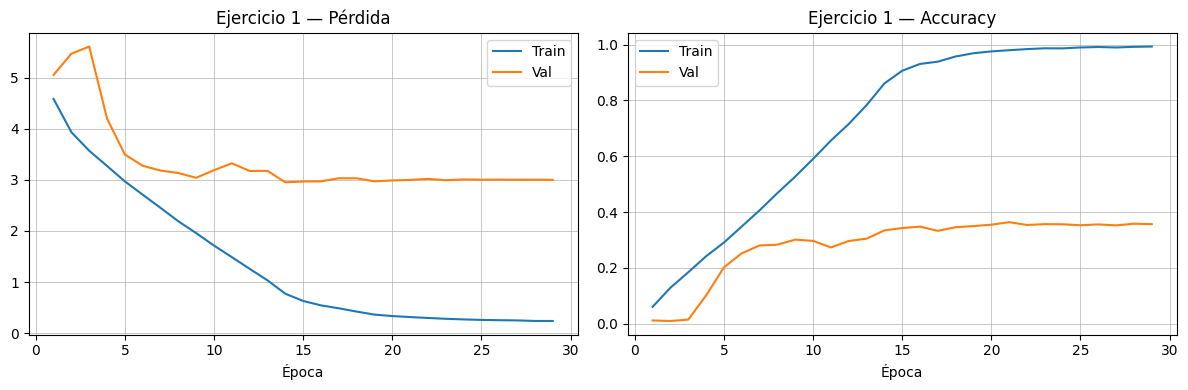

2026-04-10 18:45:18.021130: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2026-04-10 18:45:18.466774: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_213', 4 bytes spill stores, 4 bytes spill loads



2026-04-10 18:45:18.715779: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_213', 32 bytes spill stores, 32 bytes spill loads



[Test E1]  Loss: 2.9724  |  Accuracy: 0.3546


In [10]:
history_e1 = model_e1.fit(
    x_train, y_train,
    epochs=CFG["epochs_baseline"],
    batch_size=CFG["batch_size"],
    validation_data=(x_val, y_val),
    callbacks=[
        EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4),
    ],
    verbose=1,
)
plot_training(history_e1, title="Ejercicio 1")
RESULTS["E1 Supervisado"] = evaluate_and_report(model_e1, x_test, y_test, "Test E1")


---
## Ejercicio 2 — Auto-aprendizaje (*Self-Training*)

**Algoritmo:**
1. Entrenar el clasificador con los datos etiquetados.
2. Predecir sobre los datos sin etiquetar; conservar predicciones con confianza > umbral.
3. Añadir esas pseudo-etiquetas al conjunto de entrenamiento, ponderadas por su confianza.
4. Repetir durante `st_iters` iteraciones.

In [11]:
def self_training(
    x_labeled, y_labeled, x_unlabeled,
    x_val_data, y_val_data, x_test_data, y_test_data,
    n_iters=5, epochs_per_iter=20, threshold=0.95, batch_size=64,
) -> tuple:
    """
    Auto-aprendizaje iterativo con pseudo-etiquetas ponderadas por confianza.

    En cada iteración:
      - Se entrena un clasificador nuevo con los datos etiquetados acumulados.
      - Las predicciones con confianza > threshold se convierten en
        pseudo-etiquetas con peso igual a su confianza máxima.
      - Los datos pseudo-etiquetados se eliminan del pool sin etiquetar.

    Args:
        x_labeled, y_labeled: Datos etiquetados iniciales.
        x_unlabeled: Pool sin etiquetar.
        x_val_data, y_val_data: Validación (para early stopping).
        x_test_data, y_test_data: Test (para seguimiento del accuracy).
        n_iters: Número máximo de iteraciones.
        epochs_per_iter: Épocas de entrenamiento por iteración.
        threshold: Umbral de confianza mínima.
        batch_size: Tamaño de mini-lote.

    Returns:
        (best_model, test_accuracies)
    """
    train_x  = x_labeled.copy()
    train_y  = y_labeled.copy()
    pool_x   = x_unlabeled.copy()
    weights  = np.ones(len(train_y))
    test_accs = []
    best_acc, best_model = 0.0, None

    for it in range(n_iters):
        # Construir y entrenar un clasificador nuevo en cada iteración
        enc = build_conv_encoder(filters=CFG["filters"], dropout=CFG["dropout"],
                                  l2_reg=CFG["l2_reg"], name=f"enc_st{it}")
        clf = build_classifier_head(enc, CFG["num_classes"], CFG["dense_units"],
                                     CFG["dropout"], CFG["l2_reg"], name=f"clf_st{it}")
        clf.compile(optimizer=make_optimizer(), loss="categorical_crossentropy",
                    metrics=["accuracy"])
        clf.fit(
            train_x, train_y,
            sample_weight=weights,
            epochs=epochs_per_iter,
            batch_size=batch_size,
            validation_data=(x_val_data, y_val_data),
            callbacks=[EarlyStopping(monitor="val_accuracy", patience=6,
                                     restore_best_weights=True)],
            verbose=0,
        )

        _, test_acc = clf.evaluate(x_test_data, y_test_data, verbose=0)
        test_accs.append(test_acc)
        if test_acc > best_acc:
            best_acc, best_model = test_acc, clf

        # Pseudo-etiquetado
        if len(pool_x) == 0:
            print(f"Iter {it+1}: pool vacío, deteniendo.")
            break
        proba = clf.predict(pool_x, verbose=0)
        conf  = proba.max(axis=1)
        pred  = proba.argmax(axis=1)
        mask  = conf >= threshold
        n_new = mask.sum()
        if n_new > 0:
            train_x = np.concatenate([train_x, pool_x[mask]])
            train_y = np.concatenate([train_y, to_categorical(pred[mask], CFG["num_classes"])])
            weights = np.concatenate([weights, conf[mask]])
            pool_x  = pool_x[~mask]

        print(f"Iter {it+1}/{n_iters}  test={test_acc:.4f}  "
              f"añadidos={n_new}  pool={len(pool_x)}")
        tf.keras.backend.clear_session()

    return best_model, test_accs


2026-04-10 18:45:26.984533: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-10 18:45:26.984571: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2026-04-10 18:45:27.957702: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3286', 36 bytes spill stores, 36 bytes spill loads



Iter 1/5  test=0.3513  añadidos=6346  pool=33654


2026-04-10 18:48:20.765142: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2026-04-10 18:48:21.206180: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_165', 4 bytes spill stores, 4 bytes spill loads

2026-04-10 18:48:21.333840: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_154', 8 bytes spill stores, 8 bytes spill loads

2026-04-10 18:48:21.338484: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_165', 32 bytes spill stores, 32 bytes spill loads



...

2026-04-10 18:54:33.901712: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2026-04-10 18:54:34.290731: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_165', 4 bytes spill stores, 4 bytes spill loads

2026-04-10 18:54:34.375756: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_154', 8 bytes spill stores, 8 bytes spill loads



2026-04-10 18:54:34.517854: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_165', 32 bytes spill stores, 32 bytes spill loads



2026-04-10 18:54:34.776327: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_165', 4 bytes spill stores, 4 bytes spill loads



Iter 5/5  test=0.3764  añadidos=2795  pool=17487


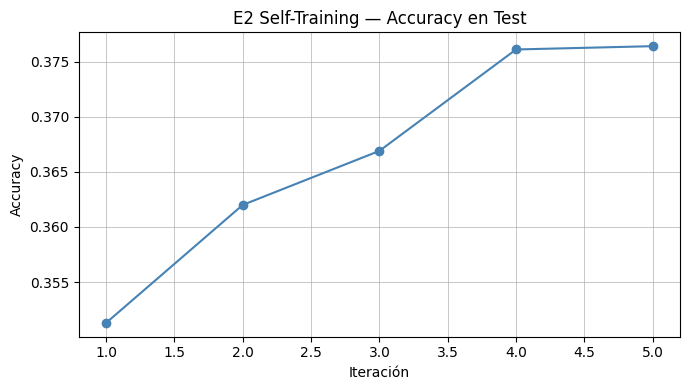

Mejor accuracy en test (E2): 0.3764


In [12]:
best_model_e2, test_accs_e2 = self_training(
    x_train, y_train, x_unlabeled,
    x_val, y_val, x_test, y_test,
    n_iters=CFG["st_iters"],
    epochs_per_iter=CFG["st_epochs"],
    threshold=CFG["st_threshold"],
    batch_size=CFG["batch_size"],
)
plot_st_progress(test_accs_e2, "E2 Self-Training — Accuracy en Test")
RESULTS["E2 Self-Training"] = {"accuracy": max(test_accs_e2)}
print(f"Mejor accuracy en test (E2): {max(test_accs_e2):.4f}")


---
## Ejercicio 3 — Autoencoder en dos pasos

**Paso 1:** Autoencoder entrenado sobre todas las imágenes (etiquetadas + sin etiquetar) minimizando el MSE de reconstrucción.

**Paso 2:** Encoder congelado + cabeza clasificadora entrenada solo con datos etiquetados.

Epoch 1/15



  1/375 ━━━━━━━━━━━━━━━━━━━━ 1:15:45 12s/step - loss: 0.1696


  3/375 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.1420   


  6/375 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.1227 


  8/375 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.1147

...


364/375 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0047


367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0047


370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0047


373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0047


375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0047 - val_loss: 0.0039


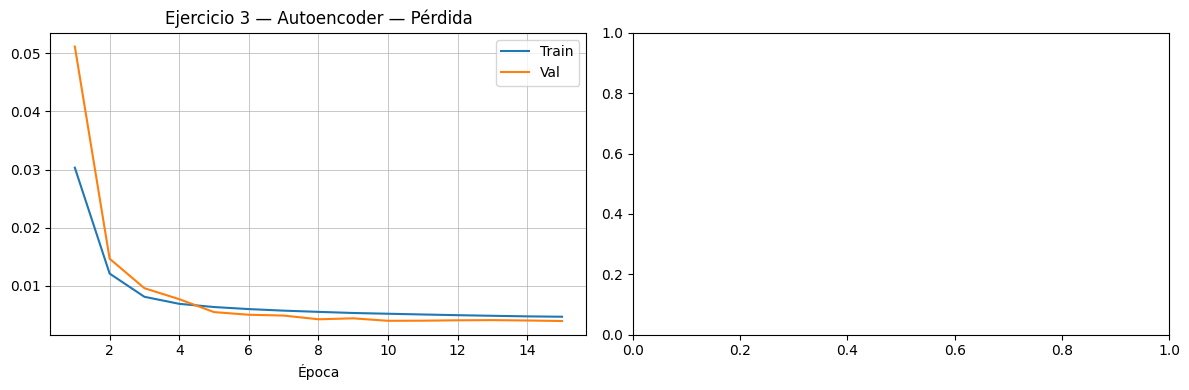

In [13]:
# Autoencoder
enc_e3 = build_conv_encoder(filters=CFG["filters"], dropout=CFG["dropout"],
                             l2_reg=CFG["l2_reg"], name="encoder_e3")
dec_e3 = build_decoder(enc_e3.output_shape[1:],
                        filters=list(reversed(CFG["filters"])), name="decoder_e3")

ae_in  = Input(shape=(32, 32, 3))
ae_e3  = Model(ae_in, dec_e3(enc_e3(ae_in)), name="autoencoder_e3")
ae_e3.compile(optimizer=Adam(learning_rate=CFG["lr"]), loss="mse")

# Paso 1: entrenar con todos los datos
x_all_ae = np.concatenate([x_train, x_unlabeled], axis=0)
history_ae_e3 = ae_e3.fit(
    x_all_ae, x_all_ae,
    epochs=CFG["epochs_ae"],
    batch_size=CFG["ae_batch_size"],
    validation_data=(x_val, x_val),
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1,
)
plot_training(history_ae_e3, title="Ejercicio 3 — Autoencoder")


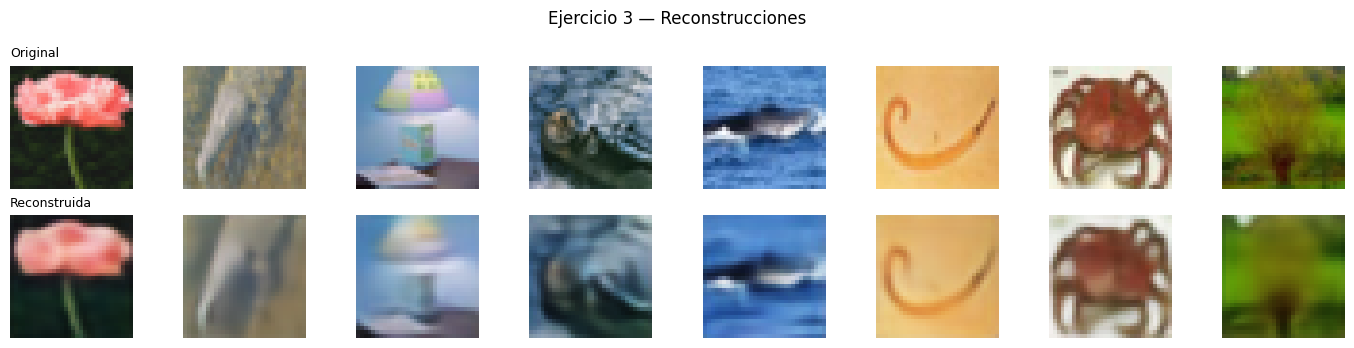

In [14]:
# Visualización de reconstrucciones
n_show = 8
samples = x_val[:n_show]
recons  = ae_e3.predict(samples, verbose=0)
fig, axes = plt.subplots(2, n_show, figsize=(14, 3.5))
for i in range(n_show):
    axes[0, i].imshow(samples[i]); axes[0, i].axis("off")
    axes[1, i].imshow(np.clip(recons[i], 0, 1)); axes[1, i].axis("off")
axes[0, 0].set_title("Original", loc="left", fontsize=9)
axes[1, 0].set_title("Reconstruida", loc="left", fontsize=9)
plt.suptitle("Ejercicio 3 — Reconstrucciones")
plt.tight_layout()
plt.show()


Epoch 1/30



  1/125 ━━━━━━━━━━━━━━━━━━━━ 11:49 6s/step - accuracy: 0.0000e+00 - loss: 5.7079


  7/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0086 - loss: 5.6074      


 13/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0118 - loss: 5.5688


 20/125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0165 - loss: 5.5052

...


 99/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9320 - loss: 0.5238


106/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9326 - loss: 0.5224


113/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9331 - loss: 0.5212


120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9336 - loss: 0.5202


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9340 - loss: 0.5194 - val_accuracy: 0.2535 - val_loss: 3.5356 - learning_rate: 4.6875e-06


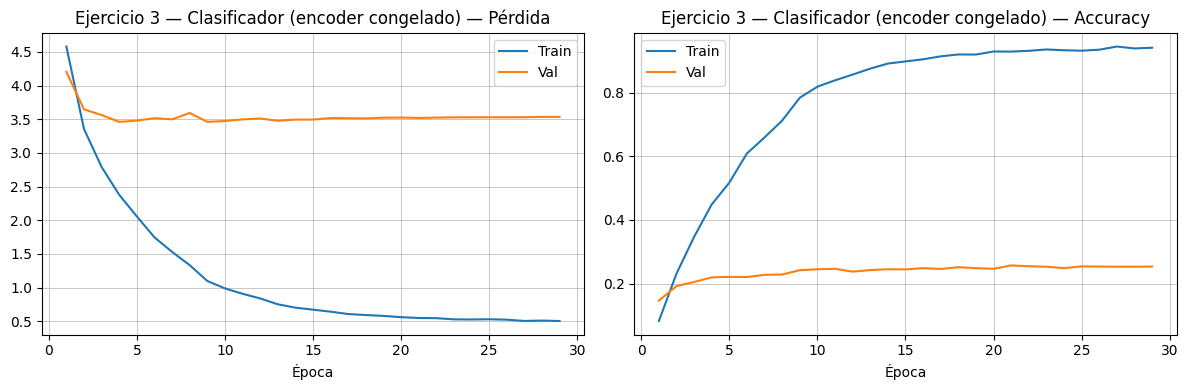

[Test E3]  Loss: 3.4617  |  Accuracy: 0.2600


In [15]:
# Paso 2: congelar encoder y entrenar clasificador
for layer in enc_e3.layers:
    layer.trainable = False

model_e3 = build_classifier_head(enc_e3, CFG["num_classes"], CFG["dense_units"],
                                  CFG["dropout"], CFG["l2_reg"], name="classifier_e3")
model_e3.compile(optimizer=make_optimizer(), loss="categorical_crossentropy",
                 metrics=["accuracy"])

history_cls_e3 = model_e3.fit(
    x_train, y_train,
    epochs=CFG["epochs_cls"],
    batch_size=CFG["batch_size"],
    validation_data=(x_val, y_val),
    callbacks=[
        EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4),
    ],
    verbose=1,
)
plot_training(history_cls_e3, title="Ejercicio 3 — Clasificador (encoder congelado)")
RESULTS["E3 Autoencoder 2-step"] = evaluate_and_report(model_e3, x_test, y_test, "Test E3")


---
## Ejercicio 4 — Entrenamiento conjunto (un paso)

El encoder se optimiza simultáneamente con dos objetivos:

- **L_recon** (MSE): reconstrucción de todas las imágenes.
- **L_cls** (entropía cruzada): clasificación de las imágenes etiquetadas.

Pérdida total: `L = L_recon + α · L_cls`  (α = `joint_alpha`)

In [16]:
class JointAutoencoderClassifier:
    """
    Entrenamiento conjunto que optimiza reconstrucción y clasificación
    en un único paso de gradiente por lote.

    El encoder compartido recibe gradientes de ambas pérdidas,
    aprendiendo representaciones útiles para ambas tareas.
    """

    def __init__(self, input_shape=(32, 32, 3), num_classes=100,
                 filters=None, dense_units=512, dropout=0.2,
                 l2_reg=1e-4, alpha=0.5, lr=3e-4, weight_decay=1e-4):
        """
        Args:
            alpha: Peso de la pérdida de clasificación relativa a reconstrucción.
        """
        if filters is None:
            filters = [64, 128, 256]
        self.alpha = alpha
        self.optimizer = AdamW(learning_rate=lr, weight_decay=weight_decay)

        self.encoder = build_conv_encoder(input_shape, filters, dropout, l2_reg, "enc_e4")
        self.decoder = build_decoder(self.encoder.output_shape[1:],
                                     list(reversed(filters)), "dec_e4")

        # Cabeza clasificadora (comparte pesos del encoder)
        x = Flatten()(self.encoder.output)
        x = Dense(dense_units, activation="relu",
                  kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout)(x)
        cls_out = Dense(num_classes, activation="softmax")(x)
        self.cls_head = Model(self.encoder.input, cls_out, name="cls_head_e4")

        self._mse = tf.keras.losses.MeanSquaredError()
        self._cce = tf.keras.losses.CategoricalCrossentropy()

    @tf.function
    def _labeled_step(self, x_b, y_b):
        """Paso con ambas pérdidas sobre un lote etiquetado."""
        with tf.GradientTape() as tape:
            enc_out  = self.encoder(x_b, training=True)
            decoded  = self.decoder(enc_out, training=True)
            pred_cls = self.cls_head(x_b, training=True)
            loss = self._mse(x_b, decoded) + self.alpha * self._cce(y_b, pred_cls)
        all_vars = (self.encoder.trainable_variables
                    + self.decoder.trainable_variables
                    + self.cls_head.trainable_variables)
        self.optimizer.apply_gradients(zip(tape.gradient(loss, all_vars), all_vars))
        return loss

    @tf.function
    def _unlabeled_step(self, x_b):
        """Paso solo con pérdida de reconstrucción sobre un lote sin etiquetar."""
        with tf.GradientTape() as tape:
            loss = self._mse(x_b, self.decoder(self.encoder(x_b, training=True), training=True))
        vars_ = self.encoder.trainable_variables + self.decoder.trainable_variables
        self.optimizer.apply_gradients(zip(tape.gradient(loss, vars_), vars_))
        return loss

    def fit(self, x_labeled, y_labeled, x_unlabeled, x_val, y_val,
            epochs=15, batch_size=64):
        """
        Entrenamiento conjunto.

        Returns:
            Historial con listas 'total_loss' y 'val_accuracy'.
        """
        ds_l = (tf.data.Dataset.from_tensor_slices((x_labeled, y_labeled))
                .shuffle(len(x_labeled), seed=SEED).batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))
        ds_u = (tf.data.Dataset.from_tensor_slices(x_unlabeled)
                .shuffle(len(x_unlabeled), seed=SEED).batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

        history = {"total_loss": [], "val_accuracy": []}
        for epoch in range(epochs):
            losses = [float(self._labeled_step(xb, yb)) for xb, yb in ds_l]
            for xb in ds_u:
                self._unlabeled_step(xb)
            val_acc = float(np.mean(
                self.cls_head.predict(x_val, verbose=0).argmax(1) == y_val.argmax(1)
            ))
            history["total_loss"].append(np.mean(losses))
            history["val_accuracy"].append(val_acc)
            print(f"Época {epoch+1}/{epochs}  loss={np.mean(losses):.4f}  val_acc={val_acc:.4f}")
        return history

    def evaluate(self, x, y):
        """Evalúa la cabeza clasificadora. Returns (loss, accuracy)."""
        preds = self.cls_head.predict(x, verbose=0)
        return float(self._cce(y, preds)), float(np.mean(preds.argmax(1) == y.argmax(1)))


In [17]:
joint_e4 = JointAutoencoderClassifier(
    input_shape=(32, 32, 3),
    num_classes=CFG["num_classes"],
    filters=CFG["filters"],
    dense_units=CFG["dense_units"],
    dropout=CFG["dropout"],
    l2_reg=CFG["l2_reg"],
    alpha=CFG["joint_alpha"],
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)

history_e4 = joint_e4.fit(
    x_train, y_train, x_unlabeled, x_val, y_val,
    epochs=CFG["epochs_ae"],
    batch_size=CFG["ae_batch_size"],
)


2026-04-10 18:58:26.641538: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-04-10 18:58:38.011702: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 1/15  loss=2.3462  val_acc=0.0250


2026-04-10 18:58:50.747356: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 2/15  loss=1.9877  val_acc=0.1115


...

Época 11/15  loss=0.5051  val_acc=0.2910


Época 12/15  loss=0.3811  val_acc=0.2970


Época 13/15  loss=0.2651  val_acc=0.3045


Época 14/15  loss=0.1998  val_acc=0.3190


Época 15/15  loss=0.1384  val_acc=0.3300


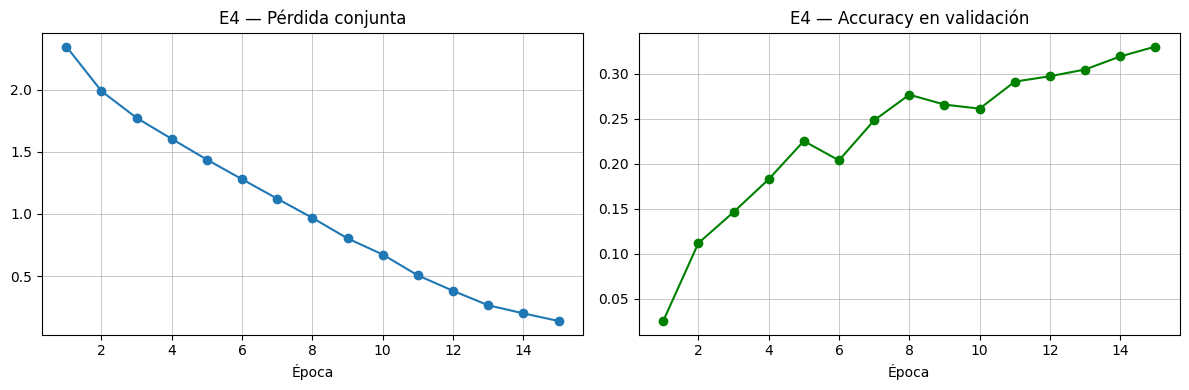

[Test E4]  Accuracy: 0.3269


In [18]:
# Curvas de entrenamiento E4
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history_e4["total_loss"]) + 1)
ax1.plot(ep, history_e4["total_loss"], "o-")
ax1.set_title("E4 — Pérdida conjunta")
ax1.set_xlabel("Época")
ax1.grid(linewidth=0.5)
ax2.plot(ep, history_e4["val_accuracy"], "o-", color="green")
ax2.set_title("E4 — Accuracy en validación")
ax2.set_xlabel("Época")
ax2.grid(linewidth=0.5)
plt.tight_layout()
plt.show()

_, test_acc_e4 = joint_e4.evaluate(x_test, y_test)
print(f"[Test E4]  Accuracy: {test_acc_e4:.4f}")
RESULTS["E4 Autoencoder 1-step"] = {"accuracy": test_acc_e4}


---
## Ejercicio 5 — Filtrado de anomalías + auto-aprendizaje

Se entrena un detector de anomalías de una clase sobre los datos etiquetados.
Las muestras del pool sin etiquetar clasificadas como anómalas se descartan
antes de aplicar el auto-aprendizaje del Ejercicio 2.

In [19]:
class AdaptiveRCallback(tf.keras.callbacks.Callback):
    """
    Actualiza el radio `r` del detector SVDD al final de cada época
    y detecta convergencia.

    Args:
        train_data: Datos sobre los que calcular el cuantil de r.
        delta: Tolerancia para declarar convergencia.
        patience: Épocas consecutivas sin cambio para detener el entrenamiento.
    """

    def __init__(self, train_data, delta=0.025, patience=3):
        super().__init__()
        self.train_data = train_data
        self.delta      = delta
        self.patience   = patience
        self._no_change = 0

    def on_epoch_end(self, epoch, logs=None):
        scores = self.model.predict(self.train_data, verbose=0).flatten()
        new_r  = float(np.sort(scores)[int(len(scores) * (1.0 - self.model.nu))])
        old_r  = float(self.model.r.numpy())
        self.model.r.assign(new_r)
        if abs(new_r - old_r) < self.delta:
            self._no_change += 1
            if self._no_change >= self.patience:
                print(f"  [AdaptiveR] Convergencia en época {epoch+1}.")
                self.model.stop_training = True
        else:
            self._no_change = 0


class OneClassDetector:
    """
    Detector de anomalías neuronal de una clase (variante SVDD).

    Aprende una frontera de decisión en torno a los datos normales.
    Muestras con puntuación < r se consideran anómalas.

    Args:
        input_shape: Forma de la imagen.
        nu: Fracción esperada de datos normales (controla la frontera).
    """

    def __init__(self, input_shape=(32, 32, 3), nu=0.9):
        self.nu = nu
        inputs = tf.keras.Input(shape=input_shape)
        x = inputs
        for f in [64, 128, 256]:
            x = Conv2D(f, (3, 3), activation="relu", padding="same")(x)
            x = BatchNormalization()(x)
            x = MaxPooling2D((2, 2))(x)
            x = Dropout(0.2)(x)
        x = Flatten()(x)
        x = Dense(512, activation="relu")(x)
        outputs = Dense(1)(x)  # puntuación de normalidad (escalar lineal)

        self.model = tf.keras.Model(inputs, outputs)
        self.model.r  = tf.Variable(1.0, trainable=False)
        self.model.nu = nu
        self.model.compile(optimizer="adam", loss=self._svdd_loss)

    def _svdd_loss(self, y_true, y_pred):
        """Penaliza puntuaciones por debajo del radio r."""
        return (1.0 / self.model.nu) * tf.reduce_mean(tf.maximum(0.0, self.model.r - y_pred))

    def fit(self, X, epochs=15, batch_size=128):
        """Entrena el detector sobre datos de la clase normal."""
        cb = AdaptiveRCallback(X, delta=CFG["ad_delta"], patience=CFG["ad_patience"])
        self.model.fit(X, np.zeros((len(X), 1), dtype="float32"),
                       epochs=epochs, batch_size=batch_size, callbacks=[cb], verbose=1)

    def filter_inliers(self, X, percentile=None):
        """
        Devuelve el subconjunto de X considerado normal (inliers).

        Args:
            X: Imágenes a filtrar.
            percentile: Cuantil de corte. Si None, se usa 1 - nu.
        """
        q       = percentile if percentile is not None else (1.0 - self.nu)
        scores  = self.model.predict(X, verbose=0).flatten()
        thr     = np.quantile(scores, q)
        mask    = scores > thr
        print(f"  {mask.sum()}/{len(X)} inliers conservados ({100*mask.mean():.1f}%)")
        return X[mask]


In [20]:
detector_e5 = OneClassDetector(nu=CFG["nu"])
detector_e5.fit(x_train, epochs=CFG["anomaly_epochs"])
x_unlabeled_clean = detector_e5.filter_inliers(x_unlabeled)


Epoch 1/15



 1/63 ━━━━━━━━━━━━━━━━━━━━ 6:53 7s/step - loss: 1.7050


 6/63 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6962


11/63 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4681


16/63 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3603

...


49/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 107.6140


55/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 98.4718 


61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 90.8874


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 87.5661


  36000/40000 inliers conservados (90.0%)


Iter 1/5  test=0.3400  añadidos=5751  pool=30249


2026-04-10 19:04:05.998631: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-10 19:04:05.998683: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-10 19:04:05.998828: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2026-04-10 19:04:06.431884: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3313', 4 bytes spill stores, 4 bytes spill loads



2026-04-10 19:04:06.634655: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3237', 4 bytes spill stores, 4 bytes spill loads

2026-04-10 19:04:06.731844: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2232', 8 bytes spill stores, 8 bytes spill loads



2026-04-10 19:04:06.904025: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2339', 32 bytes spill stores, 32 bytes spill loads

2026-04-10 19:04:07.056013: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3746', 116 bytes spill stores, 116 bytes spill loads



...

2026-04-10 19:07:51.839116: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2232', 8 bytes spill stores, 8 bytes spill loads

2026-04-10 19:07:51.965202: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2339', 32 bytes spill stores, 32 bytes spill loads



2026-04-10 19:07:52.330577: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3729', 116 bytes spill stores, 116 bytes spill loads

2026-04-10 19:07:52.335616: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3746', 116 bytes spill stores, 116 bytes spill loads

2026-04-10 19:07:52.446909: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2339', 4 bytes spill stores, 4 bytes spill loads



2026-04-10 19:07:52.533858: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3746', 68 bytes spill stores, 68 bytes spill loads



Iter 4/5  test=0.3622  añadidos=255  pool=23657


Iter 5/5  test=0.3730  añadidos=537  pool=23120


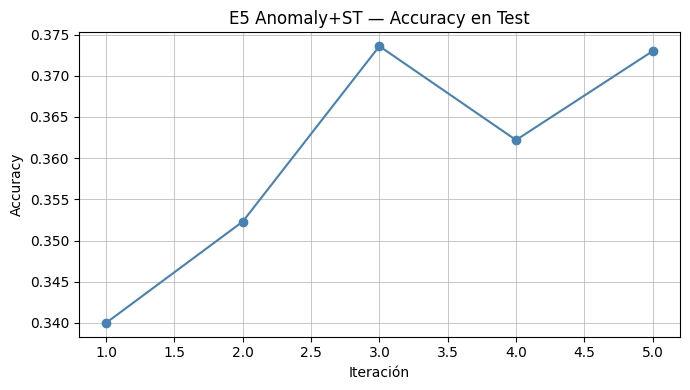

Mejor accuracy en test (E5): 0.3736


In [21]:
best_model_e5, test_accs_e5 = self_training(
    x_train, y_train,
    x_unlabeled_clean,      # pool filtrado
    x_val, y_val, x_test, y_test,
    n_iters=CFG["st_iters"],
    epochs_per_iter=CFG["st_epochs"],
    threshold=CFG["st_threshold"],
    batch_size=CFG["batch_size"],
)
plot_st_progress(test_accs_e5, "E5 Anomaly+ST — Accuracy en Test")
RESULTS["E5 Anomaly + ST"] = {"accuracy": max(test_accs_e5)}
print(f"Mejor accuracy en test (E5): {max(test_accs_e5):.4f}")


---
## Ejercicio 6 — Aprendizaje contrastivo (SCAN-*like*)

Pre-entrenamiento auto-supervisado con pérdidas de consistencia y de clúster:

1. Dos vistas aumentadas de la misma imagen deben producir representaciones similares.
2. Las asignaciones de clúster deben ser confiadas (baja entropía).

Finalmente, se entrena una cabeza clasificadora sobre las representaciones aprendidas.

In [22]:
class ConvEncoderSubclass(tf.keras.Model):
    """
    Encoder convolucional como tf.keras.Model subclass para uso con GradientTape.
    Arquitectura idéntica a build_conv_encoder.
    """

    def __init__(self, filters=None, dropout=0.2):
        super().__init__(name="conv_encoder_e6")
        if filters is None:
            filters = [64, 128, 256]
        self._layers_list = []
        for f in filters:
            self._layers_list += [
                Conv2D(f, (3, 3), activation="relu", padding="same"),
                BatchNormalization(),
                Conv2D(f, (3, 3), activation="relu", padding="same"),
                MaxPooling2D((2, 2)),
                Dropout(dropout),
            ]

    def call(self, inputs, training=False):
        x = inputs
        for layer in self._layers_list:
            x = (layer(x, training=training)
                 if isinstance(layer, (Dropout, BatchNormalization)) else layer(x))
        return x


class ContrastivePretrainer:
    """
    Pre-entrenamiento auto-supervisado con pérdidas de consistencia (InfoNCE) y de clúster.

    Pérdida total: L = L_consistency + lambda · L_cluster

    Args:
        encoder: Encoder Keras (subclass API).
        num_clusters: Número de clústeres (= número de clases).
        tau: Temperatura de la pérdida InfoNCE.
        lambda_: Peso de la pérdida de clúster.
        lr: Learning rate.
    """

    def __init__(self, encoder, num_clusters=100, tau=5.0, lambda_=0.5, lr=3e-4):
        self.encoder      = encoder
        self.cluster_head = Dense(num_clusters, activation="softmax")
        self.tau          = tau
        self.lambda_      = lambda_
        self.optimizer    = Adam(learning_rate=lr)

        self.aug1 = tf.keras.Sequential([
            RandomRotation(0.05),
            RandomTranslation(0.15, 0.15),
            RandomZoom(0.15),
        ])
        self.aug2 = tf.keras.Sequential([
            RandomTranslation(0.15, 0.15),
            Resizing(48, 48),
            RandomCrop(32, 32),
        ])

    def _encode_flat(self, x, training=False):
        z = self.encoder(x, training=training)
        return tf.reshape(z, (tf.shape(z)[0], -1))

    @tf.function
    def _train_step(self, x_batch):
        with tf.GradientTape() as tape:
            z1 = self._encode_flat(self.aug1(x_batch, training=True), training=True)
            z2 = self._encode_flat(self.aug2(x_batch, training=True), training=True)
            n  = tf.shape(x_batch)[0]

            # InfoNCE
            logits = tf.matmul(z1, z2, transpose_b=True) / self.tau
            loss_m = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(
                    tf.range(n), logits[:n, :n], from_logits=True
                )
            )
            # Clúster (entropía baja)
            c1, c2 = self.cluster_head(z1), self.cluster_head(z2)
            loss_c = tf.reduce_mean(
                tf.reduce_sum(c1 * (1 - c1), axis=1) + tf.reduce_sum(c2 * (1 - c2), axis=1)
            )
            total = loss_m + self.lambda_ * loss_c

        vars_ = self.encoder.trainable_variables + self.cluster_head.trainable_variables
        self.optimizer.apply_gradients(zip(tape.gradient(total, vars_), vars_))
        return total

    def fit(self, X, epochs=8, batch_size=128):
        """Ejecuta el pre-entrenamiento auto-supervisado sobre X."""
        ds = (tf.data.Dataset.from_tensor_slices(X)
              .shuffle(len(X), seed=SEED)
              .batch(batch_size, drop_remainder=True)
              .prefetch(tf.data.AUTOTUNE))
        losses = []
        for ep in range(epochs):
            bl = [float(self._train_step(xb)) for xb in ds]
            losses.append(np.mean(bl))
            print(f"Época {ep+1}/{epochs}  loss={losses[-1]:.4f}")
        return losses


Época 1/8  loss=9.0536


2026-04-10 19:11:34.445049: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 2/8  loss=1.4841


Época 3/8  loss=0.8185


Época 4/8  loss=0.6435


Época 5/8  loss=0.5610


Época 6/8  loss=0.5057


Época 7/8  loss=0.4999


Época 8/8  loss=0.4513


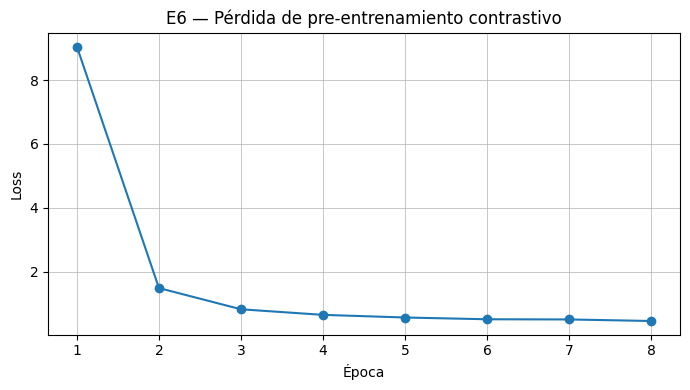

In [23]:
# Pre-entrenamiento contrastivo
enc_e6 = ConvEncoderSubclass(filters=CFG["filters"], dropout=CFG["dropout"])
_ = enc_e6(tf.zeros((1, 32, 32, 3)))  # inicializar pesos

pretrainer = ContrastivePretrainer(
    enc_e6, num_clusters=CFG["num_classes"],
    tau=CFG["cl_tau"], lambda_=CFG["cl_lambda"], lr=CFG["lr"],
)
x_all_e6 = np.concatenate([x_train, x_unlabeled], axis=0)
cl_losses = pretrainer.fit(x_all_e6, epochs=CFG["cl_epochs"])

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cl_losses) + 1), cl_losses, "o-")
plt.title("E6 — Pérdida de pre-entrenamiento contrastivo")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(linewidth=0.5)
plt.tight_layout()
plt.show()


Epoch 1/30



  1/125 ━━━━━━━━━━━━━━━━━━━━ 7:29 4s/step - accuracy: 0.0000e+00 - loss: 5.5704


 11/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0127 - loss: 5.5368     


 21/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0215 - loss: 5.4187


 29/125 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0280 - loss: 5.3269

...


 90/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1262


101/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1262


111/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1262


121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1262


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.1262 - val_accuracy: 0.2350 - val_loss: 3.8726 - learning_rate: 4.6875e-06


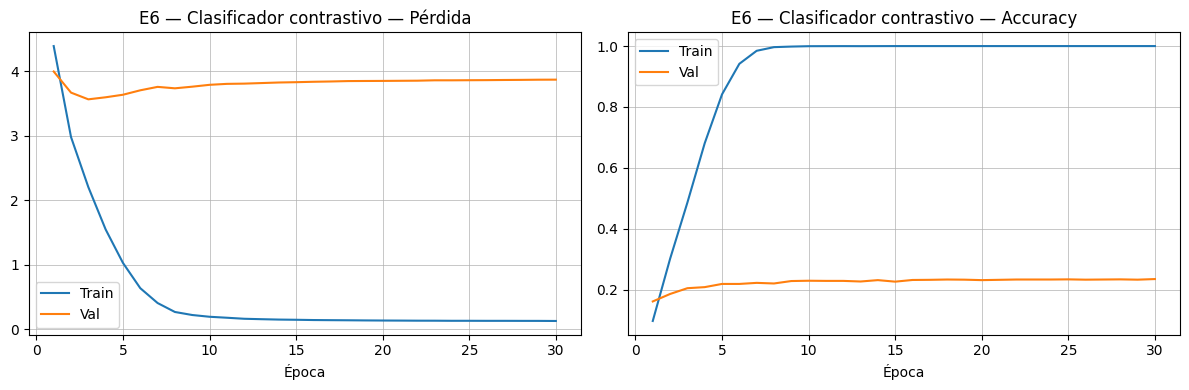

[Test E6]  Loss: 3.8627  |  Accuracy: 0.2298


In [24]:
# Extraer representaciones y entrenar clasificador lineal
def extract_features(encoder_model, X, batch_size=256):
    """Extrae y aplana las representaciones del encoder en lotes."""
    feats = []
    for i in range(0, len(X), batch_size):
        z = encoder_model(X[i:i+batch_size], training=False)
        feats.append(tf.reshape(z, (tf.shape(z)[0], -1)).numpy())
    return np.concatenate(feats, axis=0)

z_train_e6 = extract_features(enc_e6, x_train)
z_val_e6   = extract_features(enc_e6, x_val)
z_test_e6  = extract_features(enc_e6, x_test)

feat_in = Input(shape=(z_train_e6.shape[1],))
x_ = Dense(CFG["dense_units"], activation="relu",
           kernel_regularizer=regularizers.l2(CFG["l2_reg"]))(feat_in)
x_ = BatchNormalization()(x_)
x_ = Dropout(CFG["dropout"])(x_)
x_ = Dense(CFG["num_classes"], activation="softmax")(x_)
clf_e6 = Model(feat_in, x_, name="classifier_e6")
clf_e6.compile(optimizer=make_optimizer(), loss="categorical_crossentropy",
               metrics=["accuracy"])

history_e6 = clf_e6.fit(
    z_train_e6, y_train,
    epochs=CFG["epochs_cls"],
    batch_size=CFG["batch_size"],
    validation_data=(z_val_e6, y_val),
    callbacks=[
        EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4),
    ],
    verbose=1,
)
plot_training(history_e6, title="E6 — Clasificador contrastivo")
RESULTS["E6 Contrastivo"] = evaluate_and_report(clf_e6, z_test_e6, y_test, "Test E6")


---
## Resumen de resultados

Comparación de accuracy en el conjunto de test para todos los ejercicios.


Método                         Test Accuracy
E1 Supervisado                       0.3546
E2 Self-Training                     0.3764
E3 Autoencoder 2-step                0.2600
E4 Autoencoder 1-step                0.3269
E5 Anomaly + ST                      0.3736
E6 Contrastivo                       0.2298


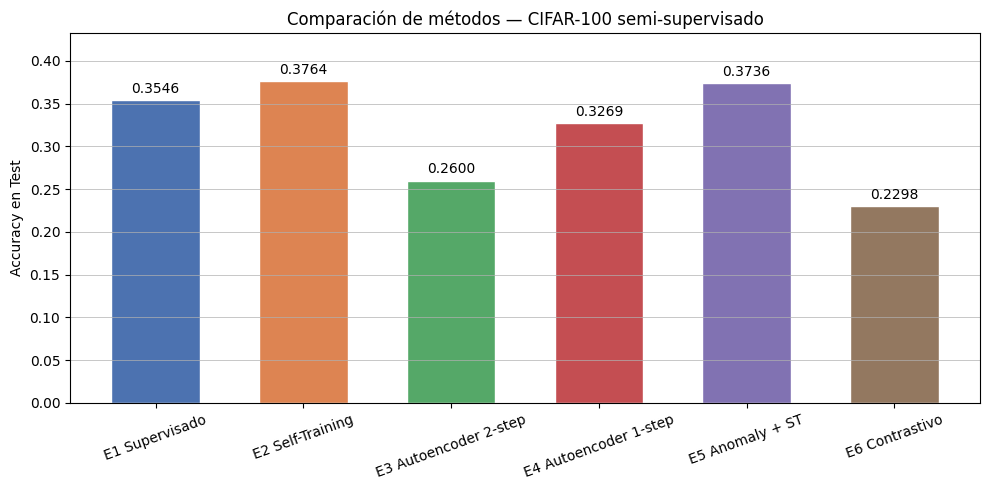

In [25]:
print("\n" + "=" * 55)
print(f"{'Método':<30} {'Test Accuracy':>12}")
print("=" * 55)
for name, metrics in RESULTS.items():
    print(f"{name:<30} {metrics.get('accuracy', float('nan')):>12.4f}")
print("=" * 55)

methods = list(RESULTS.keys())
accs    = [RESULTS[m].get("accuracy", 0) for m in methods]
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, accs, color=colors[:len(methods)], edgecolor="white", width=0.6)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_ylim(0, min(1.0, max(accs) * 1.15))
ax.set_ylabel("Accuracy en Test")
ax.set_title("Comparación de métodos — CIFAR-100 semi-supervisado")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", linewidth=0.5)
plt.tight_layout()
plt.show()
